In [ ]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:           7.8Gi       3.3Gi       184Mi        65Mi       4.7Gi       4.5Gi
Swap:             0B          0B          0B


In [1]:
%pip install qiskit qiskit_aer pylatexenc matplotlib

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import WeightedAdder
from qiskit.circuit.library.grover_operator import GroverOperator
from qiskit_aer import AerSimulator

### The Problem

We have a list of integers:
  $$
  [3,\;7,\;11,\;18]
  $$
and our goal is to find which subset of these numbers sums to a target value; in this case the target value is $21$. Probably you do not need a computer (classical or quantum) to discover that `3 + 7 + 11` and `18 + 3` are the two solutions but it's an interesting implementation of the Grover's algorithm.

One thing to bear in mind is that even for a small list of values like this, there are already $2^4 = 16$ possible subsets and as the list grows, this number increases quite rapidly (and that is where classical computers start to struggle).

We will run and measure the circuit 1024 times (`shots = 1024`) to estimate the probability of each possible solution.



In [3]:
numbers = [3, 7, 11, 18]
target = 21
shots = 1024

The **oracle** contains a problem-specific logic to recognize valid solutions by marking them (usually via a phase flip).

For this problem, one important component for the oracle, is the [Weighted Adder](https://qiskit.org/documentation/stubs/qiskit.circuit.library.WeightedAdder.html). WA takes `n` input qubits (the subset selector), computes the weighted sum (e.g. `3 + 7 + 18`), stores the result in dedicated **sum qubits**, using additional **ancilla qubits** as temporary workspace.

An overall example for one single input state (interpret the bits **from right to left** - little-endian order):

$$
|0111⟩ \;\longrightarrow\; 1\cdot 3 + 1\cdot 7 + 1\cdot 11 + 0\cdot 18 = 21
$$

The WA computes this sum **reversibly** and stores it in the sum register as a binary number, while leaving the input qubits unchanged.

This allows the oracle to check whether the sum matches the target value.

Also, think ancilla qubits as temporary "scratch" qubits used for reversible computation (required in quantum computing) and most important, must be cleaned before the oracle terminates, otherwise they would interfer with Grover's amplitude amplification.

It is important to notice here that in `total_qubits = adder.num_qubits + 1`, we are going to add an extra qubit for the ancilla.

The **input qubits** of the WA represents candidate subsets, whereas the **sum qubits** store the computed total.

In [4]:
n = len(numbers)
adder = WeightedAdder(n, weights=numbers)
total_qubits = adder.num_qubits + 1 
sum_qubits = adder.num_sum_qubits
sum_indices = list(range(n, n + sum_qubits))

Here comes our oracle circuit definition (to be used in the main circuit based on the Grover's algorithm).

After the code part, there is a visualisation of the oracle circuit self. Note that I have used **barriers** with description, to separate the logical steps. It has no physical effect on the quantum state. At the start, we add the just created adder to our `oracle` circuit which has size as number of qubits required (17). The layout of the qubits is:

* qo-q3 -> Input qubits
* q4-q9 -> Sum register (6 qubits as the sum of `3 + 7 + 11 + 18 = 39 -> 100111`)
* q10-q15 -> Ancillas used by the Adder
* q16 -> last qubit is the oracle ancilla

Before introducing the oracle’s core logic, let’s briefly review the gates involved.

The **Pauli-X gate** flips the state of a single qubit:

$$
X|0\rangle = |1\rangle \qquad
X|1\rangle = |0\rangle
$$

In matrix form:
$$
X =
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
$$

It plays the same role as a **classical NOT gate**, but operates on quantum states.

A **controlled-X gate** applies an X gate **only** if the control qubit is in state $|1\rangle$.

| Control | Target (input) | Target (output) |
|-------|----------------|-----------------|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

This introduces conditional logic into quantum circuits.

The **MCX gate** (Multi Controlled Toffoli's gates family) generalizes this idea. The X gate is applied only if *all* control qubits are $|1\rangle$ and it acts like a logical **AND** across multiple conditions.

$$
\mathrm{MCX}
=
\begin{pmatrix}
I_{2^{n+1}-2} & 0 \\
0 &
\begin{pmatrix}
0 & 1 \\
1 & 0
\end{pmatrix}
\end{pmatrix}
$$


In our oracle the control qubits encode the binary sum. The target is the ancilla qubit. The MCX triggers only when the sum matches the target value.

This conditional flip is what enables **phase kickback**.

### Phase kickback

A quantum oracle does not return a value like a classical function, instead it encodes information into the **phase** of a quantum state (this mechanism is called **phase kickback**).

Consider a Boolean function:
$$
f(x) \in \{0, 1\}
$$

A quantum oracle implements the unitary transformation:
$$
U_f |x\rangle |y\rangle = |x\rangle |y \oplus f(x)\rangle
$$

If the second register (ancilla) is prepared in the state:
$$
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}},
$$

then applying the oracle gives:
$$
U_f |x\rangle |-\rangle
= (-1)^{f(x)} |x\rangle |-\rangle
$$

The ancilla returns to its original state, but the input state acquires a phase. This is phase kickback.

#### Why |−⟩ state

The key identity is:
$$
X|-\rangle = -|-\rangle
$$

So when the oracle condition is satisfied (\(f(x) = 1\)) the ancilla is flipped, the flip produces a **global phase of −1** and the input state becomes:
  $$
  |x\rangle \rightarrow -|x\rangle
  $$

This phase change is invisible to measurement, but crucial for **interference**.

#### Deutsch and Deutsch–Jozsa

Phase kickback was first exploited in the **Deutsch algorithm** and later generalized in the **Deutsch–Jozsa algorithm** (I put a link in the below references).

There, the oracle distinguishes between constant and balanced functions, by encoding the function’s behaviour entirely in the **relative phases** of a superposition.

Grover’s algorithm uses the same idea. Solutions are marked by a phase flip, non-solutions are left unchanged.

#### The Oracle as a Phase Function

In Grover’s algorithm, the oracle effectively implements:
$$
U_f |x\rangle = (-1)^{f(x)} |x\rangle
$$

where:
$$
f(x) =
\begin{cases}
1 & \text{if } x \text{ is a valid solution} \\
0 & \text{otherwise}
\end{cases}
$$

This operation is applied **simultaneously to all \(2^n\) inputs** in superposition.

Although Grover’s algorithm provides a quadratic speedup in search, the oracle applies a phase operation to exponentially many states at once.

This exponential parallelism in representation is what makes quantum algorithms possible. Interference then determines which answers survive measurement.

Back to our example, we can see that the Pauli-X gates have been applied strategically, as the binary equivalent of `21` which is our target value, is `010101`. These are the bits from the sum. They should flip the 0s as we need a full `111111` state from the oracle. Once one input state gives the right answer, as for what just discussed, its phase is flipped. Then the state is reverted (re-applying the same X-gates). This avoid to "corrupt" the adder and ancillas entanglements. The goal of the oracle is about changing phase only (mark/tag the right solution), not data.

Finally why there is an `adder_dg` at the end of the graph? It is needed to uncompute the sum. In classical computing would be something like

```
temp = expensive_calculation(x)
if temp == target:
    mark_solution()
del temp <-- temp gets deleted
```

`dg` stands for dagger (Hermitian adjoint). For any unitary operator $U$, the Hermitian adjoint equals its inverse:

$$
U^\dagger = U^{-1} \;\;\Rightarrow\;\; U^\dagger U = U U^\dagger = I
$$

One last thing here, the `MCX + |->` can actually be replaced by a single `MCZ` (multi controlled Z) that acts directly on the phase. However the first makes the explaination clearer not hiding parts.

In [5]:
oracle = QuantumCircuit(total_qubits, name="Oracle")

oracle.barrier(label="Oracle Start")
oracle.append(adder, range(adder.num_qubits))

oracle.barrier(label="WeightedAdder")
target_bin = format(target, f'0{sum_qubits}b')[::-1]

# this is a "trick" - set to 1 all 0s values that eventually represents 21, to activate the controlled gate MCX
for i, bit in enumerate(target_bin):
    if bit == '0': 
        oracle.x(sum_indices[i])

oracle.barrier(label="Target X-flip")
oracle.mcx(sum_indices, total_qubits - 1)

# revert to avoid adder corruptions and ancillas entanglements
oracle.barrier(label="Phase Flip")
for i, bit in enumerate(target_bin):
    if bit == '0': 
        oracle.x(sum_indices[i])

oracle.barrier(label="Undo X-flip")
oracle.append(adder.inverse(), range(adder.num_qubits))

oracle.barrier(label="Oracle End")

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(17, "q"), index=0>, <Qubit register=(17, "q"), index=1>, <Qubit register=(17, "q"), index=2>, <Qubit register=(17, "q"), index=3>, <Qubit register=(17, "q"), index=4>, <Qubit register=(17, "q"), index=5>, <Qubit register=(17, "q"), index=6>, <Qubit register=(17, "q"), index=7>, <Qubit register=(17, "q"), index=8>, <Qubit register=(17, "q"), index=9>, <Qubit register=(17, "q"), index=10>, <Qubit register=(17, "q"), index=11>, <Qubit register=(17, "q"), index=12>, <Qubit register=(17, "q"), index=13>, <Qubit register=(17, "q"), index=14>, <Qubit register=(17, "q"), index=15>, <Qubit register=(17, "q"), index=16>), clbits=())

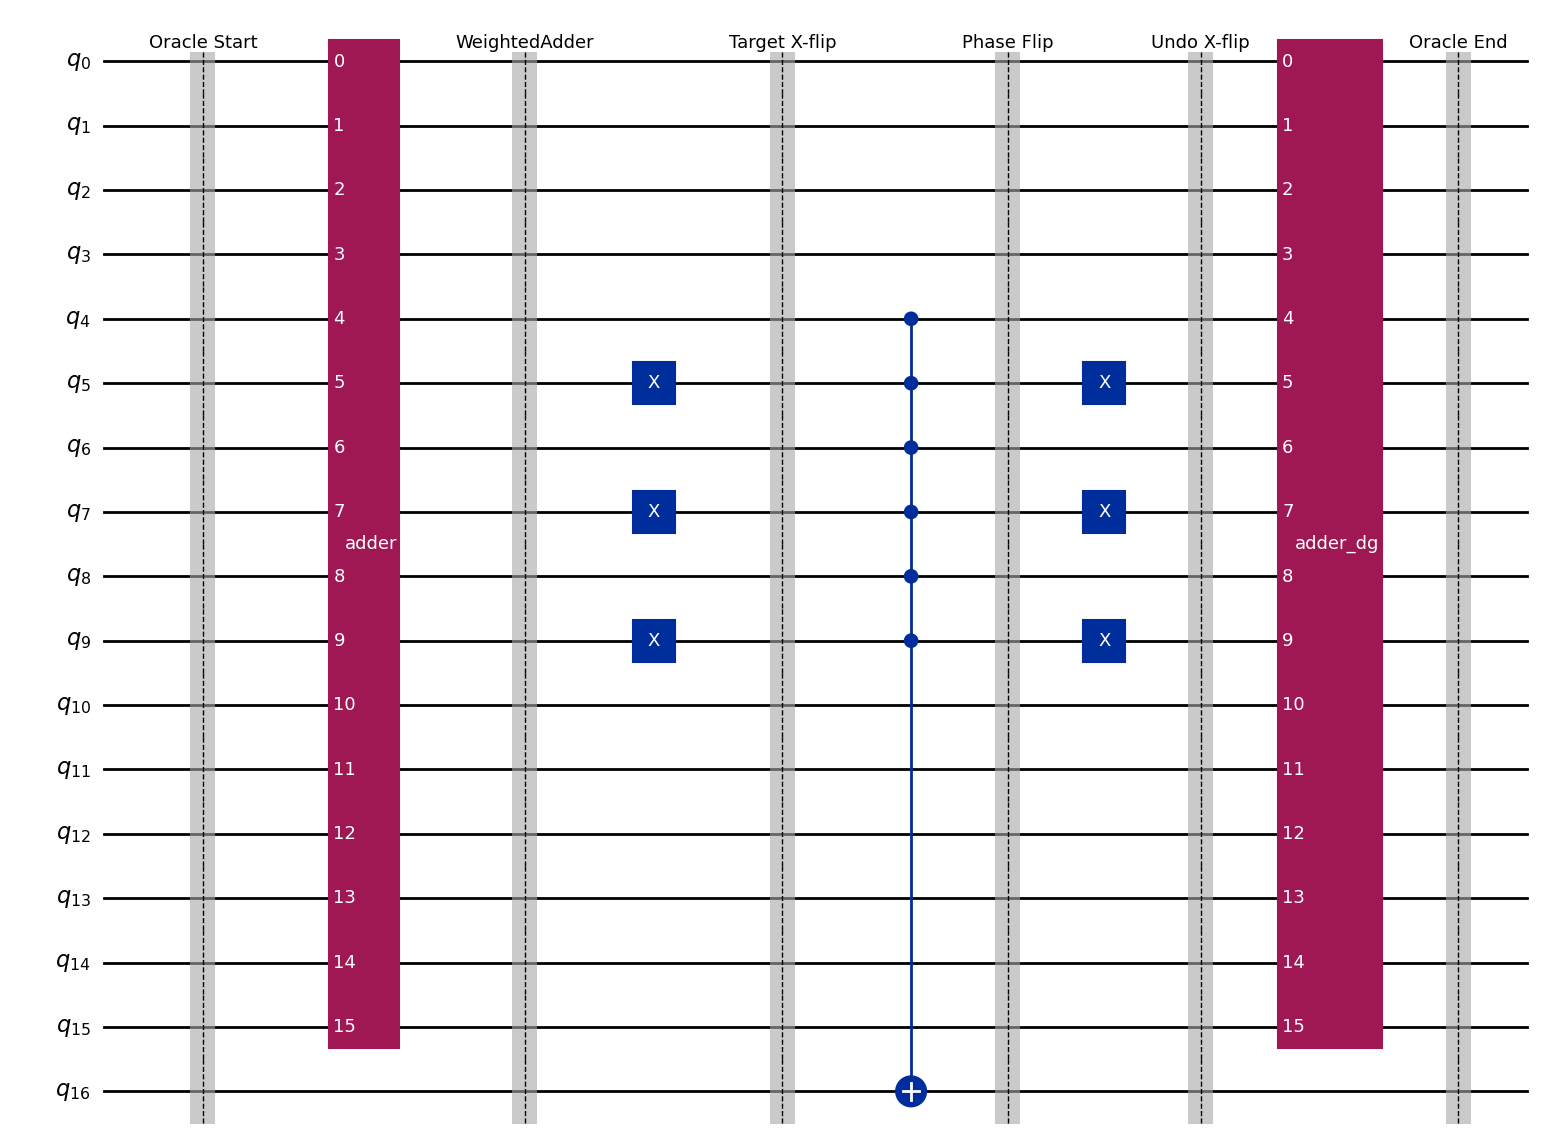

In [6]:
from qiskit.visualization import circuit_drawer
circuit_drawer(oracle, output='mpl')

We can now pass the oracle solution to the Grover Operator (builtin function from Qiskit). What this does is to "amplify" the amplitude (and so the probability) of the values in input marked as right solution and orthogonal to what is called the **diffuser**. I put here a short description of the algorithm and its main parts. You will find some links in the description for a more complete explanation of the Grover's algorithm.

The Grover operator is the composition of two reflections

$$
\mathcal{G} = U_s \, U_\omega
$$

where the oracle is defined as

$$
U_\omega = I - 2 \lvert \omega \rangle \langle \omega \rvert
$$

and the diffuser (inversion about the mean) is

$$
U_s = 2 \lvert s \rangle \langle s \rvert - I
$$

with the uniform superposition state

$$
\lvert s \rangle = \frac{1}{\sqrt{N}} \sum_{x=0}^{N-1} \lvert x \rangle
$$

The initial state can be decomposed into solution and non-solution subspaces

$$
\lvert s \rangle =
\sqrt{\frac{N-M}{N}} \, \lvert s' \rangle
+
\sqrt{\frac{M}{N}} \, \lvert \omega \rangle
$$

where

- $|s'\rangle$ is the normalized superposition of non-solution states  
- $|\omega\rangle$ is the normalized superposition of solution states  
- $M$ is the number of solutions  
- $N$ is the total number of states

Each Grover iteration performs a rotation in the two-dimensional space
spanned by $\lvert s' \rangle$ and $\lvert \omega \rangle$

$$
\mathcal{G}^k \lvert s \rangle =
\cos \big(\frac{2k+1}{2}\theta\big) \lvert s' \rangle
+
\sin \big(\frac{2k+1}{2}\theta\big) \lvert \omega \rangle
$$

with

$$
\sin^2 \theta = \frac{M}{N}
$$

Each Grover iteration rotates the quantum state vector closer to the solution subspace, by approximately $ 2\theta $, where $ \theta \approx \sqrt{M/N} $, and after about $\sqrt{N/M}$ steps the correct answers dominate the measurement statistics. These are the two main steps followed per iteration that generate the rotation caused by two reflections

 * the oracle reflection is applied to the initial state that geometrically corresponds to a reflection of the state $|s>$ around $|s'>$ (the amplitude of $|\omega>$ state becomes negative, lowering the average amplitude).
 * the diffuser reflection corresponds to the reflection around $|s>$ which boosts the negative amplitude of $|\omega> and reduces even more the others.

<div style="text-align: center;">
    <img src="images/grover_rotation.png" width="500"/>
    <p><em>Grover rotation in the solution subspace</em></p>
</div>

In [ ]:
grover_op = GroverOperator(oracle, reflection_qubits=list(range(n)))

/tmp/ipykernel_2460/2346201667.py:1: DeprecationWarning: The class ``qiskit.circuit.library.grover_operator.GroverOperator`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. Use qiskit.circuit.library.grover_operator instead.
  grover_op = GroverOperator(oracle, reflection_qubits=list(range(n)))


Finally the main circuit (code and image) that defines the input state vector, the oracle ancilla and the application of the Grover's operator (that we just saw) to the input state.

#### Input state after the Hadamard gates

Applying a Hadamard gate to a single qubit maps

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \qquad
H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

and applying Hadamard gates to all $n$ input qubits creates a uniform superposition of all $2^n$ computational basis states.

$$
H|0\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}, \qquad
H|1\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

that will turn our input state to (applies tensor product across transformed qubits)

$$
|s\rangle
= H^{\otimes n} |0\rangle^{\otimes n}
= \frac{1}{\sqrt{2^n}} \sum_{x=0}^{2^n - 1} |x\rangle
$$

or more explicitly

$$
|s\rangle =
\frac{1}{4}(
|0000\rangle +
|0001\rangle +
|0010\rangle +
|0011\rangle +
|0100\rangle +
|0101\rangle +
|0110\rangle +
|0111\rangle +
|1000\rangle +
|1001\rangle +
|1010\rangle +
|1011\rangle +
|1100\rangle +
|1101\rangle +
|1110\rangle +
|1111\rangle
)
$$

so each basis state has an equal probability of $(\frac{1}{4})^2 = 0.0625$.

#### The oracle ancilla state

The oracle uses a single ancilla qubit prepared as (after applying Pauli-X gate and Hadamard)

$$
|-\rangle = \frac{|0\rangle - |1\rangle}{\sqrt{2}}
$$

As we saw, when the oracle condition is satisfied, the multi-controlled gate flips the ancilla. Because the ancilla is in $|-\rangle$, this flip kicks back a phase of $-1$ onto the input state (phase kickback), without changing any measured bit.

#### Why `grover_op.power(2)`

Grover’s algorithm rotates the state vector in a 2D subspace spanned by $|K\rangle$ (solution states) and $|J\rangle$ (non-solution states).

The rotation angle per Grover iteration is

$$
\theta \approx 2 \sqrt{\frac{M}{N}}
$$

Where $N = 2^n$ total states and $M$ number of solutions.

The optimal number of Grover iterations is

$$
k \approx \left\lfloor \frac{\pi}{4} \sqrt{\frac{N}{M}} \right\rfloor
$$

Applied to this example, $n = 4 \Rightarrow N = 16$ and $M = 2$ (two valid subsets), we get

$$
k \approx \frac{\pi}{4} \sqrt{\frac{16}{2}} \approx 2.2 \Rightarrow 2
$$

That’s why the circuit uses `2` in `qc.append(grover_op.power(2), range(total_qubits))` that also means "loop twice" the same oracle + diffuser operation. This loop is "unrolled" as repeated operations are written out explicitly as gates rather than represented as a loop or a single abstract instruction.

However it is not always easy to know or discover this value. Generally with too few iterations the solutions won't get amplified enough and with too many, the *rotation* past the solution and you get lose of probabaility.

Each application performs two reflections -> one rotation, increasing the probability of measuring the correct subsets.

In [10]:
qc = QuantumCircuit(total_qubits, n)

# SUPERPOSITION INPUT
qc.h(range(n))
qc.barrier(label="Superposition")

# ANCILLA AS |->
qc.x(total_qubits - 1)
qc.h(total_qubits - 1)
qc.barrier(label="Ancilla as |->")

# UNROLLED ITERATION (2) OF GROVER'S OPERATOR
qc.append(grover_op.power(2), range(total_qubits))
qc.barrier(label="Grover Iterations")

# MEASUREMENT
qc.measure(range(n), range(n))
qc.barrier(label="Measurement")

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=17, num_clbits=0, params=[]), qubits=(<Qubit register=(17, "q"), index=0>, <Qubit register=(17, "q"), index=1>, <Qubit register=(17, "q"), index=2>, <Qubit register=(17, "q"), index=3>, <Qubit register=(17, "q"), index=4>, <Qubit register=(17, "q"), index=5>, <Qubit register=(17, "q"), index=6>, <Qubit register=(17, "q"), index=7>, <Qubit register=(17, "q"), index=8>, <Qubit register=(17, "q"), index=9>, <Qubit register=(17, "q"), index=10>, <Qubit register=(17, "q"), index=11>, <Qubit register=(17, "q"), index=12>, <Qubit register=(17, "q"), index=13>, <Qubit register=(17, "q"), index=14>, <Qubit register=(17, "q"), index=15>, <Qubit register=(17, "q"), index=16>), clbits=())

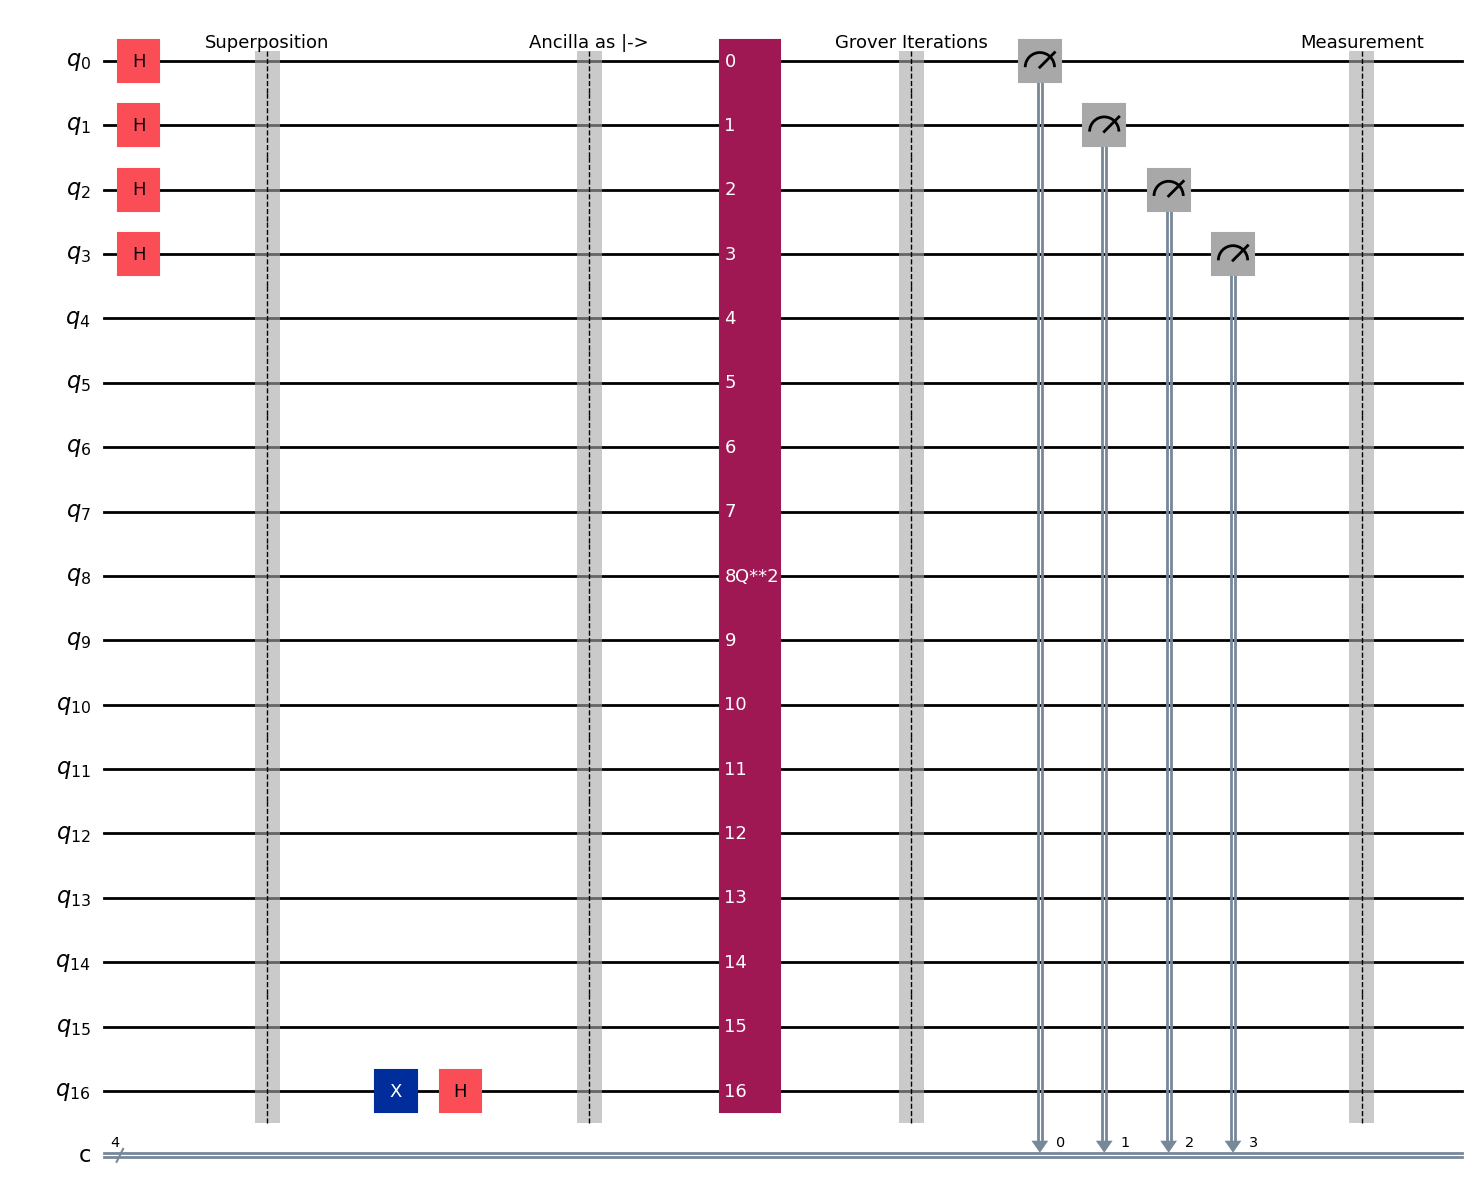

In [11]:
circuit_drawer(qc, output='mpl')

The circuit is now ready to run using the below code.

`AerSimulator` runs the quantum circuit on your local machine, emulating the behavior of an ideal (or noisy) quantum processor. This line can later be swapped with a real quantum backend or a cloud-based quantum service (for example IBM Quantum) with no changes to the algorithm logic.

`transpile()` (transpilation) rewrites the circuit into the native gates and topology supported by the chosen backend (simulator or real device) as quantum hardware does not understand abstract circuits.
Think of it as a compiler step for quantum hardware.

`counts` represents the result of our measurements. Quantum measurements are inherently probabilistic so running the circuit multiple times (shots = 1024 as defined initially) samples the output distribution.

In [ ]:
sim = AerSimulator()
t_qc = transpile(qc, sim)
counts = sim.run(t_qc, shots=shots).result().get_counts()

These are an example of counts returned by the circuit after running it (as Python's dictionary sorted by the highest count).

As you can see, two states have a very high count respect the others: 513 out 1024 counts (`1001`) and 452 out of 1024 (`0111`) that represents the solutions

$$
1001 \;\longrightarrow\; 1\cdot 18 + 0\cdot 11 + 0\cdot 7 + 1\cdot 3
= 18 + 3
= 21
$$

and

$$
0111 \;\longrightarrow\; 0\cdot 18 + 1\cdot 11 + 1\cdot 7 + 1\cdot 3
= 11 + 7 + 3
= 21
$$


In [13]:
print(dict(sorted(counts.items(), key=lambda item: item[1], reverse=True)))

{'1001': 513, '0111': 452, '1000': 11, '0001': 6, '0011': 5, '1010': 4, '1110': 4, '0101': 4, '1011': 4, '0000': 4, '1101': 4, '1100': 3, '0100': 3, '0010': 3, '0110': 2, '1111': 2}


Quantum algorithms do not return a single answer, but a probability distribution and Grover’s algorithm works by reshaping that distribution so the correct answers dominate. 

Below is a clearer visualisation of the results using MatPlotLib. The initial state is represented on the upper part of the image showing that all the basis states have same amplitude (and therefore probability). 

At this point we do not know yet what are the solutions yet (highlighted in yellow). 

The lower distribution instead, shows the final state after passing through the circuit. 

The circuit correctly has amplified the the amplitudes and so the probabilities of the correct solutions, making them much more likely to be observed.

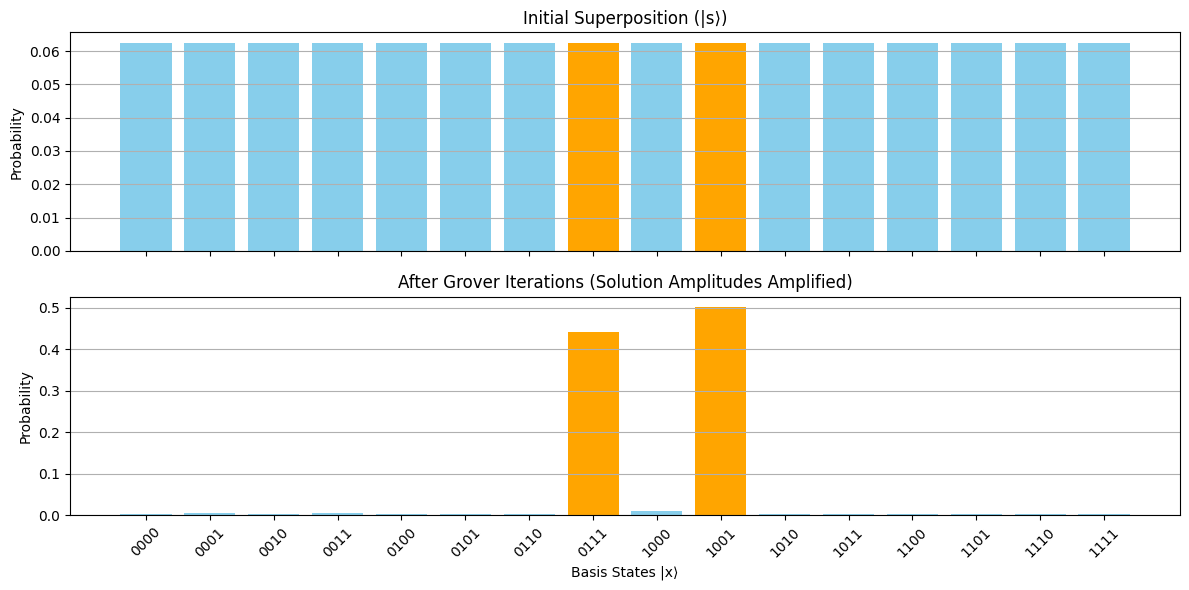

In [14]:
import matplotlib.pyplot as plt
import numpy as np

def plot_quantum_amplitudes_highlight(initial_counts, final_counts, solution_states, n_qubits=4):
    # All possible basis states
    basis_states = [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]

    # Convert counts to probabilities (normalize)
    def counts_to_probs(counts_dict):
        total = sum(counts_dict.values())
        probs = np.array([counts_dict.get(state, 0)/total for state in basis_states])
        return probs

    initial_probs = counts_to_probs(initial_counts)
    final_probs = counts_to_probs(final_counts)

    # Colors: highlight solutions
    def get_colors(states):
        return ['orange' if s in solution_states else 'skyblue' for s in states]

    # Plot
    fig, axs = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    # Initial
    axs[0].bar(basis_states, initial_probs, color=get_colors(basis_states))
    axs[0].set_title("Initial Superposition (|s⟩)")
    axs[0].set_ylabel("Probability")
    axs[0].grid(True, axis='y')

    # Final
    axs[1].bar(basis_states, final_probs, color=get_colors(basis_states))
    axs[1].set_title("After Grover Iterations (Solution Amplitudes Amplified)")
    axs[1].set_ylabel("Probability")
    axs[1].set_xlabel("Basis States |x⟩")
    axs[1].grid(True, axis='y')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

solution_states = ['1001', '0111']
initial_counts = {format(i, '04b'): 64 for i in range(16)}
final_counts = counts


plot_quantum_amplitudes_highlight(initial_counts, final_counts, solution_states, n_qubits=4)

## References

- [Qiskit Project – Official Homepage](https://qiskit.org)
- [IBM Quantum Documentation](https://quantum.ibm.com/docs)
- (book) Nielsen, M. A., & Chuang, I. L. - *Quantum Computation and Quantum Information* - Cambridge University Press
- L. K. Grover (1996), "A fast quantum mechanical algorithm for database search", Proceedings of the 28th Annual ACM Symposium on the Theory of Computing (STOC 1996), [doi:10.1145/237814.237866](http://doi.acm.org/10.1145/237814.237866), [arXiv:quant-ph/9605043](https://arxiv.org/abs/quant-ph/9605043)
- David Deutsch and Richard Jozsa (1992). "Rapid solutions of problems by quantum computation". Proceedings of the Royal Society of London A. 439: 553–558. [doi:10.1098/rspa.1992.0167](https://doi.org/10.1098%2Frspa.1992.0167)
- [List of Quantum Gates (Wikipedia)](https://en.wikipedia.org/wiki/Quantum_logic_gate)